# 01 Advanced Tokenization

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement advanced tokenization (subword, BPE-style)
- Handle morphologically rich languages
- Choose tokenization strategies for different models

## 🔗 Where this fits

**Builds on:** Course 07 — Unit 1, lesson 01 "Text Preprocessing" — normalisation decides what a token can be; this lesson decides where the boundaries go.

**Used later in:** Course 07 — Unit 4, whose BERT and GPT models are built on exactly this subword vocabulary, and Course 10 (AIAT 124) — Unit 2.

---


## 🌍 Why this matters: the same sentence costs up to 15× more in some languages

Where the boundaries go is not a stylistic choice — it has a price tag. Petrov, La Malfa, Torr & Bibi ran
commercial language-model tokenizers over the *same* text translated into many languages and found
tokenized lengths differing **by up to 15×** between languages
([arXiv:2305.15425](https://arxiv.org/abs/2305.15425), NeurIPS 2023). Ahia et al. followed the money across
22 typologically diverse languages on a commercial API and reported the consequence directly: because these
services bill **per token**, "speakers of a large number of the supported languages are overcharged while
obtaining poorer results" ([arXiv:2305.13707](https://arxiv.org/abs/2305.13707)). Same meaning, same
paragraph — more tokens means more money, more latency, and less of your document fitting in the model's
context window.

That lands on Arabic work directly. Arabic glues clitics to the following word (the article `ال`, the
conjunction `و`, prepositions `ب` and `ل`) and inflects heavily, so a vocabulary fitted on English shatters
ordinary Arabic words into many pieces. It is why the ALLaM project treats **vocabulary expansion** as a
first-class step — "second-language acquisition via vocabulary expansion and pretraining on a mixture of
Arabic and English text" — rather than an afterthought
([arXiv:2407.15390](https://arxiv.org/abs/2407.15390)).

**What goes wrong without this lesson.** In Unit 1 the naive tokenizer produced `language` and `language.`
as two unrelated symbols. Scale that up: a model with a fixed word vocabulary meets a word it has never
seen — a name, a product code, a Saudi city, a typo — and has *no symbol at all* for it. Subword
tokenization is the fix: unfamiliar words get spelled out of familiar pieces, so the vocabulary never runs
out. Sennrich, Haddow & Birch introduced exactly this for translation, gaining **+1.1 BLEU
(English→German) and +1.3 BLEU (English→Russian)** over a back-off dictionary baseline on the WMT 15 tasks
([arXiv:1508.07909](https://arxiv.org/abs/1508.07909)).

## 📥 Inputs & 📤 Outputs

**Inputs:** a two-line sample text about NLP defined in the code cell, one real English corpus for
learning BPE merges (Jane Austen's *Emma*, ~162k words, via NLTK), the same sentence in English and in
Arabic, and — where available offline — the real GPT-2 and BERT tokenizers. Plus `re`,
`collections.Counter`, and Matplotlib.

**Outputs:** word tokens with a top-5 frequency list, the text split into sentences, character 3-gram
subwords for the word "processing", naive suffix-stripping stemming examples, a **BPE merge storyboard**
(the same five words re-segmented after 0, 10, 30, 60, 100 and 150 learned merges), and a **fertility
chart** measuring how many tokens the same sentence costs in English versus Arabic — all computed live.

---


In [1]:
# Worked example: four ways to slice the same text — words, sentences, subwords, stems.
# Why it matters: the tokenization you choose decides what your model can "see";
# subword pieces are how modern models (BERT, GPT) handle words they never met.

"""
Unit 2 - Example 1: Advanced Tokenization

This example demonstrates:
1. Word tokenization
2. Sentence tokenization
3. Subword tokenization
4. Morphological analysis
"""

import re
from collections import Counter

print("=" * 60)
print("Example 1: Advanced Tokenization")
print("=" * 60)

# Sample text
sample_text = """
Natural Language Processing is amazing! It helps computers understand human language.
We can tokenize text into words, sentences, or even subwords. This is fundamental to NLP.
"""

print("\nOriginal Text:")
print(sample_text)

# 1. Word Tokenization
print("\n" + "=" * 60)
print("1. Word Tokenization")
print("=" * 60)

def word_tokenize(text):
    """
    Simple word tokenization.
    """
    # Remove punctuation and split
    text = re.sub(r'[^\w\s]', '', text)
    words = text.lower().split()
    return words

words = word_tokenize(sample_text)
print(f"\nWords: {words}")
print(f"Total words: {len(words)}")

# Word frequency
word_freq = Counter(words)
print("\nMost common words:")
for word, freq in word_freq.most_common(5):
    print(f"  {word}: {freq}")

# 2. Sentence Tokenization
print("\n" + "=" * 60)
print("2. Sentence Tokenization")
print("=" * 60)

def sentence_tokenize(text):
    """
    Simple sentence tokenization.
    """
    # Split on sentence endings
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    return sentences

sentences = sentence_tokenize(sample_text)
print(f"\nSentences: {len(sentences)}")
for i, sentence in enumerate(sentences, 1):
    print(f"  {i}. {sentence}")

# 3. Subword Tokenization
print("\n" + "=" * 60)
print("3. Subword Tokenization")
print("=" * 60)

def subword_tokenize(word, n=3):
    """
    Create n-gram subwords.
    """
    subwords = []
    for i in range(len(word) - n + 1):
        subwords.append(word[i:i+n])
    return subwords

example_word = "processing"
subwords = subword_tokenize(example_word, n=3)
print(f"\nWord: {example_word}")
print(f"3-gram subwords: {subwords}")

# 4. Morphological Analysis Example
print("\n" + "=" * 60)
print("4. Morphological Analysis")
print("=" * 60)

# Simple stemming example
# The suffix list is written out by hand — remember that; a later cell checks whether
# BPE can rediscover these same suffixes from letter-pair counts alone.
suffixes = ['ing', 'ed', 's', 'es', 'ly', 'er', 'est']

def simple_stem(word):
    """
    Simple stemming (remove common suffixes).
    """
    for suffix in suffixes:
        if word.endswith(suffix):
            return word[:-len(suffix)]
    return word

test_words = ['running', 'jumped', 'cats', 'quickly', 'faster']
print("\nStemming examples:")
for word in test_words:
    stem = simple_stem(word)
    print(f"  {word} -> {stem}")

print("\n" + "=" * 60)
print("Example completed successfully!")
print("=" * 60)
print("\nNote: For production, use libraries like NLTK, spaCy, or transformers")


Example 1: Advanced Tokenization

Original Text:

Natural Language Processing is amazing! It helps computers understand human language.
We can tokenize text into words, sentences, or even subwords. This is fundamental to NLP.


1. Word Tokenization

Words: ['natural', 'language', 'processing', 'is', 'amazing', 'it', 'helps', 'computers', 'understand', 'human', 'language', 'we', 'can', 'tokenize', 'text', 'into', 'words', 'sentences', 'or', 'even', 'subwords', 'this', 'is', 'fundamental', 'to', 'nlp']
Total words: 26

Most common words:
  language: 2
  is: 2
  natural: 1
  processing: 1
  amazing: 1

2. Sentence Tokenization

Sentences: 4
  1. Natural Language Processing is amazing
  2. It helps computers understand human language
  3. We can tokenize text into words, sentences, or even subwords
  4. This is fundamental to NLP

3. Subword Tokenization

Word: processing
3-gram subwords: ['pro', 'roc', 'oce', 'ces', 'ess', 'ssi', 'sin', 'ing']

4. Morphological Analysis

Stemming examples

## From fixed n-grams to learned pieces: BPE

The 3-grams above were **fixed width and blind to the corpus** — `pro`, `roc`, `oce`… would come out the
same whether the text was English, Arabic or a phone book. Byte Pair Encoding does the opposite: it starts
from single characters and repeatedly glues together **the pair that occurs most often in a real corpus**,
recording each glue as a *merge*. After a few hundred merges the frequent pieces of that language have
become single symbols, and rare words are still spellable from the leftovers.

Below we learn a merge table from ~162,000 words of real English text and then watch five words
re-segment as merges accumulate. Nothing about English morphology is programmed in — only pair counts.


BPE training corpus: Jane Austen's Emma — 161,600 words, 7,079 distinct word types



First 16 merges, in the order BPE learned them:
  ['e + _', 't + _', 'd + _', 's + _', 't + h', 'e + r', 'i + n', 'y + _', 'a + n', 'o + _', 'o + u', 'o + n', 'e + n', 'er + _', 'h + a', 'f + _']

Our simple_stem() was handed this suffix list by a human: ['ing', 'ed', 's', 'es', 'ly', 'er', 'est']
Which of them did BPE work out for itself, from letter-pair counts alone —
and does the order it learned them in follow how common they are in the corpus?

  suffix | learned at merge | share of corpus words ending in it
       s |               #4 |                             9.14%
      er |              #14 |                             4.09%
      ed |              #17 |                             3.37%
     ing |              #23 |                             3.01%
      ly |              #63 |                             1.74%
      es |              #70 |                             1.09%
     est |   never (in 150) |                             0.26%

How often does each demo word 

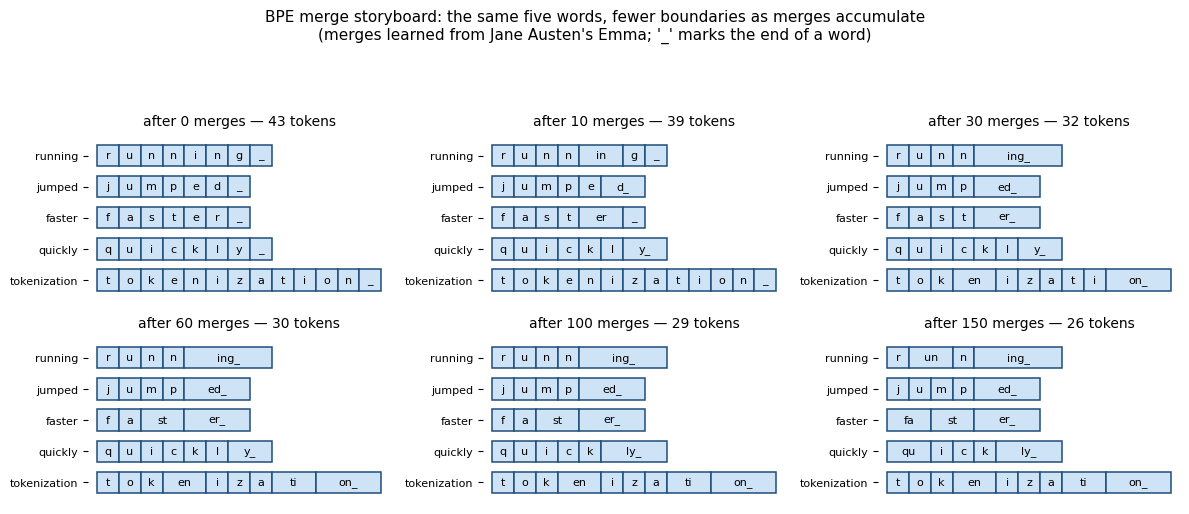

In [2]:
# Real BPE, not n-grams: learn a merge table from a corpus, then watch words glue together.
# WHY: the 3-grams above were fixed-width and blind to frequency. BPE *learns* which character
# pairs deserve to be one symbol — that learned table is what BERT and GPT actually ship with.

import collections
import matplotlib.pyplot as plt

# --- 1. A real English corpus to learn the merges from ------------------------------
# Jane Austen's "Emma" via NLTK: ordinary English prose, ~162k words, already on disk.
try:
    from nltk.corpus import gutenberg
    corpus_words = [w.lower() for w in gutenberg.words("austen-emma.txt") if w.isalpha()]
    CORPUS_NAME = "Jane Austen's Emma"
except Exception:                     # corpus unavailable -> fall back to this notebook's own text
    corpus_words = [w for w in words if w.isalpha()]
    CORPUS_NAME = "this notebook's sample text"
corpus_freq = collections.Counter(corpus_words)
print(f"BPE training corpus: {CORPUS_NAME} — {len(corpus_words):,} words, "
      f"{len(corpus_freq):,} distinct word types")


# --- 2. Train: repeatedly merge the most frequent adjacent symbol pair --------------
def bpe_train(freq, n_merges):
    """Learn a merge table. Every word starts split into characters + an end-of-word marker."""
    vocab = {" ".join(w) + " </w>": c for w, c in freq.items()}
    merges = []
    for _ in range(n_merges):
        pairs = collections.Counter()
        for w, c in vocab.items():
            symbols = w.split()
            for i in range(len(symbols) - 1):
                pairs[(symbols[i], symbols[i + 1])] += c    # pair counts weighted by word frequency
        if not pairs:
            break
        best = pairs.most_common(1)[0][0]                   # the single most frequent pair wins
        merges.append(best)
        # Glue that pair everywhere it occurs, then look for the next most frequent pair.
        vocab = {w.replace(" ".join(best), "".join(best)): c for w, c in vocab.items()}
    return merges


def bpe_segment(word, merges):
    """Apply a learned merge table to one word, in the order the merges were learned."""
    symbols = list(word) + ["</w>"]
    for a, b in merges:
        i, out = 0, []
        while i < len(symbols):
            if i < len(symbols) - 1 and symbols[i] == a and symbols[i + 1] == b:
                out.append(a + b)
                i += 2
            else:
                out.append(symbols[i])
                i += 1
        symbols = out
    return symbols


N_MERGES = 150
merges = bpe_train(corpus_freq, N_MERGES)
shown = [" + ".join(m).replace("</w>", "_") for m in merges[:16]]
print(f"\nFirst 16 merges, in the order BPE learned them:\n  {shown}")
# Did BPE rediscover the suffixes our stemmer had hard-coded? Check, do not assume.
merge_strings = ["".join(m).replace("</w>", "_") for m in merges]
print("\nOur simple_stem() was handed this suffix list by a human:", suffixes)
print("Which of them did BPE work out for itself, from letter-pair counts alone —")
print("and does the order it learned them in follow how common they are in the corpus?\n")
n_corpus_tokens = sum(corpus_freq.values())
rows = []
for suf in suffixes:
    key = suf + "_"
    rank = merge_strings.index(key) + 1 if key in merge_strings else None
    share = sum(c for w, c in corpus_freq.items()
                if w.endswith(suf) and len(w) > len(suf)) / n_corpus_tokens
    rows.append((suf, rank, share))
print(f"  {'suffix':>6s} | {'learned at merge':>16s} | {'share of corpus words ending in it':>34s}")
for suf, rank, share in sorted(rows, key=lambda r: -r[2]):       # sort by frequency, not by rank
    at = f"#{rank}" if rank else f"never (in {N_MERGES})"
    print(f"  {suf:>6s} | {at:>16s} | {share:>33.2%}")

# --- 3. Frame grid: the same five words, re-segmented as merges accumulate ----------
DEMO = ["running", "jumped", "faster", "quickly", "tokenization"]
STEPS = [0, 10, 30, 60, 100, N_MERGES]
# "tokenization" is deliberately a word the corpus never contains -- the unseen-word test.
print("\nHow often does each demo word occur in the training corpus?")
print("  " + ", ".join(f"{w}: {corpus_freq.get(w, 0)}" for w in DEMO))

print("\nStep table — total tokens needed for those five words:")
print(f"  {'merges learned':>15s} | {'tokens':>6s}")
for k in STEPS:
    total = sum(len(bpe_segment(w, merges[:k])) for w in DEMO)
    print(f"  {k:>15d} | {total:>6d}")

def piece_width(p):
    """Draw each piece as wide as the text it covers (the '</w>' marker counts as 1)."""
    return len(p.replace("</w>", "")) + (1 if p.endswith("</w>") else 0)

fig, axes = plt.subplots(2, 3, figsize=(12.0, 5.2))
span = max(len(w) + 1 for w in DEMO)
for ax, k in zip(axes.ravel(), STEPS):
    segs = [bpe_segment(w, merges[:k]) for w in DEMO]
    for row, (w, pieces) in enumerate(zip(DEMO, segs)):
        y, x = len(DEMO) - 1 - row, 0.0
        for p in pieces:
            wd = piece_width(p)
            ax.add_patch(plt.Rectangle((x, y - 0.34), wd, 0.68, facecolor="#cfe3f7",
                                       edgecolor="#1f4e79", linewidth=1.1))
            ax.text(x + wd / 2, y, p.replace("</w>", "_"), ha="center", va="center", fontsize=8)
            x += wd
    ax.set_xlim(-0.4, span + 0.4)
    ax.set_ylim(-0.7, len(DEMO) - 0.3)
    ax.set_yticks(range(len(DEMO)))
    ax.set_yticklabels(DEMO[::-1], fontsize=8)
    ax.set_xticks([])
    ax.set_title(f"after {k} merges — {sum(len(s) for s in segs)} tokens", fontsize=10)
    for spine in ax.spines.values():
        spine.set_visible(False)
fig.suptitle(f"BPE merge storyboard: the same five words, fewer boundaries as merges accumulate\n"
             f"(merges learned from {CORPUS_NAME}; '_' marks the end of a word)", fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()


**Read the storyboard.** Every panel shows the *same five words* occupying the *same width* — only the
number of boxes changes. At 0 merges each word is a row of single letters (43 boxes in total). By 30
merges the whole suffix `ing_` is one box on *running*, `ed_` one box on *jumped*, `er_` one box on
*faster*; by 100 merges `ly_` is one box on *quickly*, and the total has fallen from 43 boxes to 29.
Read left-to-right, top-to-bottom: the boundaries inside each word disappear one by one.

Two things to take from it, both visible above:

- **BPE found most of the suffixes that our hand-written stemmer had to be told.** The `simple_stem`
  function earlier carried a human-written list `['ing', 'ed', 's', 'es', 'ly', 'er', 'est']`. BPE was
  given nothing but letter-pair counts, and the table printed above shows it made `s_` a single symbol at
  merge #4, `er_` at #14, `ed_` at #17, `ing_` at #23, `ly_` at #63 and `es_` at #70 — six of the seven.
  That table is sorted by how common each suffix is in the corpus, and the merge numbers come out in
  exactly the same order: the more often a suffix ends a word, the earlier BPE glues it together. `est`
  is last on frequency (0.26% of words) and is the one suffix BPE never reached in 150 merges.
- **BPE finds frequent pieces, not morphemes.** Look at *running* in the last panel: `r | un | n | ing_`,
  not the linguistically correct `run + ning`. And *tokenization* — a word that appears **zero** times in
  the training corpus — is still spellable, in 9 pieces (`t | o | k | en | i | z | a | ti | on_`). That is
  exactly the property that keeps a subword vocabulary from ever running out on an unseen word.
  Frequency is not grammar; it is only a very good and very cheap substitute for it.


## What the boundaries cost: fertility

The opening section claimed that the same sentence can cost several times more tokens in one language than
another. That is measurable in one line, so let us measure it rather than assert it.

**Fertility** = tokens ÷ words. It is the number to quote when someone asks why an Arabic deployment costs
more than the English pilot, because tokens are simultaneously the billing unit, the latency driver, and
the thing your context window is measured in. Below we run the *same sentence* — once in English, once in
Arabic — through two real tokenizers that shipped with real models.


gpt2: first 10 Arabic pieces -> ['Ùħ', 'Ø¹', 'Ø§ÙĦ', 'Ø', '¬', 'Ø©', 'ĠØ§ÙĦ', 'ÙĦ', 'Ø', 'º']
bert-base-uncased: first 10 Arabic pieces -> ['م', '##ع', '##ا', '##ل', '##ج', '##ة', 'ا', '##ل', '##ل', '##غ']

                 GPT-2: English  13 tokens (1.18/word) | Arabic  67 tokens (6.09/word)  ->  x5.2

     BERT-base-uncased: English  13 tokens (1.18/word) | Arabic  61 tokens (5.55/word)  ->  x4.7

Characters: English 85, Arabic 71 — the Arabic sentence is shorter, yet costs far more tokens.


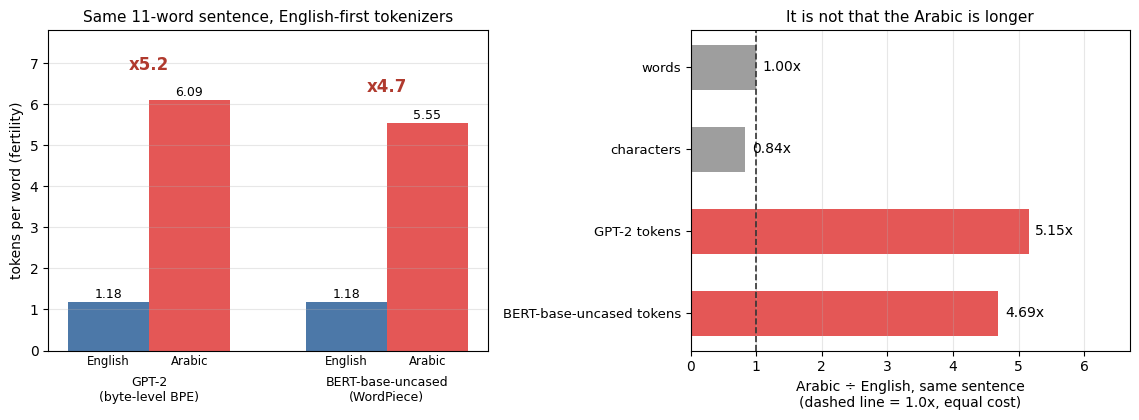

In [3]:
# Measure fertility (tokens per word) for the same sentence in English and Arabic.
# WHY: "Arabic costs more tokens" is an assertion until you count. Two real production
# tokenizers, one sentence, one translation of it — the gap is the whole lesson.

import numpy as np

EN_SENT = "Natural Language Processing is amazing! It helps computers understand human language."
AR_SENT = "معالجة اللغة الطبيعية مذهلة! إنها تساعد الحواسيب على فهم اللغة البشرية."   # same meaning
N_WORDS = len(EN_SENT.split())        # 11 whitespace-separated words in BOTH sentences

# --- Load real tokenizers that shipped with real models (offline from the local cache) ---
WANTED = {"gpt2": "GPT-2\n(byte-level BPE)", "bert-base-uncased": "BERT-base-uncased\n(WordPiece)"}
counts = {}       # label -> (english tokens, arabic tokens)
try:
    from transformers import AutoTokenizer
    for model_id, label in WANTED.items():
        try:
            try:                       # prefer the local cache: no network, no warning banner
                tok = AutoTokenizer.from_pretrained(model_id, local_files_only=True)
            except Exception:
                tok = AutoTokenizer.from_pretrained(model_id)
            counts[label] = (len(tok.encode(EN_SENT, add_special_tokens=False)),
                             len(tok.encode(AR_SENT, add_special_tokens=False)))
            pieces = [tok.convert_ids_to_tokens(i)
                      for i in tok.encode(AR_SENT, add_special_tokens=False)][:10]
            print(f"{model_id}: first 10 Arabic pieces -> {pieces}")
        except Exception as exc:
            print(f"{model_id}: unavailable offline ({type(exc).__name__}) — skipped")
except ImportError:
    print("transformers not installed — skipped")

if not counts:    # fall back to the BPE we trained above: also an English-fitted vocabulary
    def our_tokens(text):
        return sum(len(bpe_segment(w, merges)) for w in text.split())
    counts["our BPE\n(trained above, English)"] = (our_tokens(EN_SENT), our_tokens(AR_SENT))

for label, (en, ar) in counts.items():
    print(f"\n{label.splitlines()[0]:>22s}: English {en:3d} tokens ({en / N_WORDS:.2f}/word)"
          f" | Arabic {ar:3d} tokens ({ar / N_WORDS:.2f}/word)  ->  x{ar / en:.1f}")
print(f"\nCharacters: English {len(EN_SENT)}, Arabic {len(AR_SENT)} — the Arabic sentence is "
      f"{'shorter' if len(AR_SENT) < len(EN_SENT) else 'longer'}, yet costs far more tokens.")

# --- Two panels: the fertility gap, and the proof that length is not the cause -------
labels = list(counts)
en_fert = [counts[l][0] / N_WORDS for l in labels]
ar_fert = [counts[l][1] / N_WORDS for l in labels]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.3))
x, w = np.arange(len(labels)), 0.34
bars = list(ax1.bar(x - w / 2, en_fert, w, color="#4C78A8"))
bars += list(ax1.bar(x + w / 2, ar_fert, w, color="#E45756"))
for b in bars:
    ax1.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.10,
             f"{b.get_height():.2f}", ha="center", fontsize=9)
for i in range(len(labels)):
    ax1.text(i, max(en_fert[i], ar_fert[i]) + 0.75, f"x{ar_fert[i] / en_fert[i]:.1f}",
             ha="center", fontsize=12, fontweight="bold", color="#B03A2E")
# Label each bar directly (minor ticks) instead of a legend that would sit on top of the bars.
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_xticks(np.concatenate([x - w / 2, x + w / 2]), minor=True)
ax1.set_xticklabels(["English"] * len(labels) + ["Arabic"] * len(labels), minor=True, fontsize=8.5)
ax1.tick_params(axis="x", which="major", pad=18, length=0)
ax1.tick_params(axis="x", which="minor", length=0)
ax1.set_ylabel("tokens per word (fertility)")
ax1.set_ylim(0, max(ar_fert) * 1.28)
ax1.set_title(f"Same {N_WORDS}-word sentence, English-first tokenizers", fontsize=11)
ax1.grid(axis="y", alpha=0.3)

# Ratios on one clean axis: words, characters, then tokens from each tokenizer.
ratio_labels = ["words", "characters"] + [l.splitlines()[0] + " tokens" for l in labels]
ratios = [1.0, len(AR_SENT) / len(EN_SENT)] + [counts[l][1] / counts[l][0] for l in labels]
y = np.arange(len(ratio_labels))
ax2.barh(y, ratios, height=0.55, color=["#9E9E9E", "#9E9E9E"] + ["#E45756"] * len(labels))
for yy, r in zip(y, ratios):
    ax2.text(r + 0.10, yy, f"{r:.2f}x", va="center", fontsize=10)
ax2.axvline(1.0, color="#333333", ls="--", lw=1.2)
ax2.set_yticks(y)
ax2.set_yticklabels(ratio_labels, fontsize=9.5)
ax2.invert_yaxis()
ax2.set_xlim(0, max(ratios) * 1.3)
ax2.set_xlabel("Arabic \u00f7 English, same sentence\n(dashed line = 1.0x, equal cost)")
ax2.set_title("It is not that the Arabic is longer", fontsize=11)
ax2.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


**Read the chart.** *Left:* each tokenizer gets a pair of bars, English (blue) then Arabic (red). The
blue English bars sit near 1 token per word for both tokenizers — English
words mostly survive as single tokens. The red Arabic bars, for a translation of the very same sentence,
stand several times higher, and the bold red multiplier above each pair is that gap. *Right:* the two grey
bars establish that the Arabic sentence is not bigger — it has exactly the same number of words (1.00x) and
in fact **fewer characters** (bar below 1.0x, left of the dashed line) — while the red token bars sit far to
the right of the dashed equal-cost line. Same meaning, less text, several times the tokens.

So the cost is not length. It is **vocabulary fit**: neither of these tokenizers reserved many symbols for
Arabic, so Arabic falls back to near-per-character pieces — visible in the printed Arabic pieces above,
where whole words dissolve into single letters and byte fragments. Nothing errors; the bill simply grows.

That is the mechanism behind the published numbers this notebook opened with — Petrov et al. measured
tokenized lengths differing by up to **15x** across languages on commercial tokenizers
([arXiv:2305.15425](https://arxiv.org/abs/2305.15425)), and Ahia et al. traced the overcharging that
follows ([arXiv:2305.13707](https://arxiv.org/abs/2305.13707)). Our single sentence and two tokenizers land
in the same direction at a smaller magnitude, which is what one sentence can honestly show.

**In class, in one line:** run your own text through the tokenizer of the model you are about to pay for,
divide tokens by words, and compare that with the English number before you sign anything.


## 💬 Discuss

Use the printed output above, not opinions about tokenizers in general.

1. Our stemmer turned `running -> runn` but `jumped -> jump`. A colleague wants to ship it anyway because
   "it is right four times out of five". For a **search engine**, is a wrong stem worse than no stem at
   all? Now answer the same question for a **spam filter**. Why do the two answers differ?
2. The 3-gram subwords of `processing` came out as `['pro','roc','oce','ces','ess','ssi','sin','ing']` —
   fixed width, blind to meaning. BPE instead *learns* which pieces are frequent in a corpus. What would
   BPE trained on Arabic keep as single pieces that BPE trained on English would not? What does that
   predict about running an English-trained tokenizer over Arabic customer messages?
3. Your team is building an assistant for a Saudi ministry and pays per token. A larger Arabic vocabulary
   cuts the token count per message but makes the embedding table bigger. Where would you spend — a bigger
   vocabulary, or a smaller model? Name the one measurement that would settle it, and the one result that
   would change your mind.

---

## ✅ Summary

**What you actually did here** (all shown in the printed output above):

- Word-tokenized the sample text with a regex — 26 tokens; only *language* and *is* appear twice (see the top-5 list)
- Split the text into 4 sentences on `.!?`
- Built character 3-gram subwords for *processing* — the core idea behind BPE-style subword tokenizers
- Applied a naive suffix-stripping stemmer — note the failure `running -> runn`, which is exactly why
  production systems use real stemmers/lemmatizers (NLTK, spaCy)
- **Trained a real BPE merge table** on ~162k words of English and read the merge storyboard: the five
  demo words fell from 43 tokens to 26, and `er_`/`ed_`/`ing_`/`ly_` were discovered from frequency
  alone — the same suffixes the stemmer had hard-coded
- **Measured fertility** (tokens ÷ words) for one sentence in English and in Arabic with real
  tokenizers: same word count, fewer Arabic characters, several times the Arabic tokens

**Next steps:**
- `02_word_embeddings_word2vec.ipynb` — from tokens to vectors
- `exercises/01_tokenization_exercise.ipynb` — multilingual tokenization

## ⚠️ Where this breaks

Everything above assumes **a word is a run of Latin letters between spaces.** That assumption fails often,
and it fails hardest for the languages in this room.

- **Regex word tokenization** (`re.sub(r'[^\w\s]', '', text)`) destroys the token in exactly the cases that
  matter: `COVID-19`, `+966...`, `user@example.com`, `1,250.75 SAR`, `#عاجل`. Use a tokenizer that knows
  token *types* before you reach for a blanket regex.
- **Sentence splitting on `.!?`** breaks on `Dr. Ahmed`, `3.14`, `www.tvtc.gov.sa`, and on Arabic text,
  which uses `؟` and `،` — characters that are not in that class at all. Our splitter found exactly 4
  sentences here only because the sample text was written to be easy.
- **Suffix-stripping stemmers assume suffixes are glued to the end of a stem.** Arabic morphology is
  templatic: `كتب / كاتب / مكتوب / كتاب` share a root woven *through* the word rather than appended to it,
  so a Porter-style stemmer has nothing to grip. Use a morphological analyser built for Arabic instead.
- **Character n-grams are not BPE.** Fixed 3-grams ignore frequency entirely; BPE
  ([arXiv:1508.07909](https://arxiv.org/abs/1508.07909)) and SentencePiece
  ([arXiv:1808.06226](https://arxiv.org/abs/1808.06226)) *learn* their merges from data. Never report
  n-gram results as if they were subword-model results.

**The assumption that must hold:** your tokenizer was fitted on text that looks like your input. When it
was not — English tokenizer, Arabic input — nothing raises an error. You simply get a quietly worse model
and a larger bill.

**The cheaper alternative when it does not hold:** do not train a tokenizer at all. Load the one that ships
with the pretrained model you intend to use (`AutoTokenizer.from_pretrained(...)`, Unit 4). A tokenizer
that does not match its model is a silent correctness bug, not a tuning choice.

## 🔭 State of the field (2026)

Almost nobody trains a tokenizer any more. You inherit the one that shipped with your model, and the
question that replaced "which tokenizer?" is "which model's tokenizer can afford my language?" The number
practitioners quote is **fertility** — tokens produced per word — because it sets context consumption,
latency, and on a paid API the bill. Two changes since 2024 shrank the Arabic penalty without removing it:
training recipes built for Arabic *and* English together rather than bolting Arabic onto an English-first
model ([arXiv:2407.15390](https://arxiv.org/abs/2407.15390)), and open model families that widened stated
language coverage from 29 to 119 languages between two releases
([arXiv:2505.09388](https://arxiv.org/abs/2505.09388)). Byte-level fallbacks mean a modern tokenizer no
longer fails outright on unfamiliar script — it just gets expensive, quietly.

That is exactly why this lesson stays. Fertility, context cost, and the "shredded Arabic" failure you will
meet in Unit 4 are unreadable unless you have seen by hand how a word becomes word pieces and how a merge
table is learned from frequency. Counting tokens per word on your own text is a one-line diagnostic — and it
is the first thing to check when an Arabic deployment costs several times what the English pilot did.


## 📚 References

Where these ideas come from — seminal papers first, then a modern survey, then the 2024-2026 multilingual picture:

1. Sennrich, R., Haddow, B., & Birch, A. (2016). *Neural Machine Translation of Rare Words with Subword Units*. ACL 2016. [arXiv:1508.07909](https://arxiv.org/abs/1508.07909)
2. Kudo, T., & Richardson, J. (2018). *SentencePiece: A Simple and Language Independent Subword Tokenizer and Detokenizer for Neural Text Processing*. EMNLP 2018. [arXiv:1808.06226](https://arxiv.org/abs/1808.06226)
3. Mielke, S. J., Alyafeai, Z., Salesky, E., et al. (2021). *Between Words and Characters: A Brief History of Open-Vocabulary Modeling and Tokenization in NLP*. [arXiv:2112.10508](https://arxiv.org/abs/2112.10508)
4. Jurafsky, D. & Martin, J. H. (2025). *Speech and Language Processing* (3rd ed. draft) — chapters on tokenization and morphology. <https://web.stanford.edu/~jurafsky/slp3/>
5. Bari, M. S., Alnumay, Y., Alzahrani, N. A., Alotaibi, N. M., Alyahya, H. A., et al. (2024). *ALLaM: Large Language Models for Arabic and English*. [arXiv:2407.15390](https://arxiv.org/abs/2407.15390) — an Arabic-and-English training recipe rather than Arabic bolted onto an English-first model.
6. Yang, A., Li, A., Yang, B., Zhang, B., Hui, B., et al. (2025). *Qwen3 Technical Report*. [arXiv:2505.09388](https://arxiv.org/abs/2505.09388) — an open model family whose stated language coverage grew from 29 to 119 languages between releases.
